# Setup Environment

In [1]:
# Import libraries

# Standard libraries
import time
from pathlib import Path

# Data manipulation and visualization libraries
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# Models
import sklearn 

## Preprocessing and pipeline 
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Modeling
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import PredefinedSplit, RandomizedSearchCV
from lightgbm import LGBMRegressor

# Tuning and evaluation
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

# Model Interpretability
from sklearn.inspection import permutation_importance
import shap

# Saving and loading models
import joblib

print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"seaborn version: {sns.__version__}")
print(f"Scikit-Learn version: {sklearn.__version__}")

NumPy version: 2.3.5
pandas version: 3.0.3
matplotlib version: 3.11.0
seaborn version: 0.13.2
Scikit-Learn version: 1.9.0


In [2]:
# Create image and model directories if they don't exist

eda_plots_dir             = Path("plots/EDA")
tuning_plots_dir          = Path("plots/Tuning")
evaluation_plots_dir      = Path("plots/Evaluation")
features_plots_dir        = Path("plots/Features")
models_dir                = Path("models")

eda_plots_dir.mkdir(parents=True, exist_ok=True)
tuning_plots_dir.mkdir(parents=True, exist_ok=True)
evaluation_plots_dir.mkdir(parents=True, exist_ok=True)
features_plots_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

# Data Loading and Exploratory Data Analysis (EDA)

In [3]:
# Load train set and validation set

train_df = pd.read_csv(filepath_or_buffer="./data/Train.csv",
                       parse_dates=["saledate"],
                       low_memory=False).sort_values(by="saledate", ascending=True)

valid_df = pd.read_csv(filepath_or_buffer="./data/Valid.csv",
                       parse_dates=["saledate"])

valid_solution = pd.read_csv(filepath_or_buffer="./data/ValidSolution.csv")
# Map the SalePrice from the valid_solution DataFrame to the valid_df DataFrame based on SalesID
valid_df["SalePrice"] = valid_df["SalesID"].map(valid_solution.set_index("SalesID")["SalePrice"])
# Sort the valid_df DataFrame by "saledate" in ascending order and reset the index
valid_df = valid_df.sort_values("saledate", ascending=True).reset_index(drop=True)

print(f"[INFO] Number of samples in training DataFrame: {len(train_df)}")
print(f"[INFO] Number of samples in validation DataFrame: {len(valid_df)}")

[INFO] Number of samples in training DataFrame: 401125
[INFO] Number of samples in validation DataFrame: 11573


In [4]:
# Feature Engineering: Add date columns

def add_datetime_features_to_df(df, date_column="saledate"):
    # Add datetime parameters for saledate
    df["saleYear"] = df[date_column].dt.year
    df["saleMonth"] = df[date_column].dt.month
    df["saleDay"] = df[date_column].dt.day
    df["saleDayofweek"] = df[date_column].dt.dayofweek
    df["saleDayofyear"] = df[date_column].dt.dayofyear

    # Drop original saledate column
    df.drop("saledate", axis=1, inplace=True)

    return df

train_df = add_datetime_features_to_df(df=train_df)
valid_df = add_datetime_features_to_df(df=valid_df)
train_df.iloc[:, -5:].sample(5)

,saleYear,saleMonth,saleDay,saleDayofweek,saleDayofyear
38678,1998,3,3,1,62
313206,2009,3,4,2,63
251267,2002,3,12,1,71
241617,2003,4,1,1,91
102877,2000,4,18,1,109


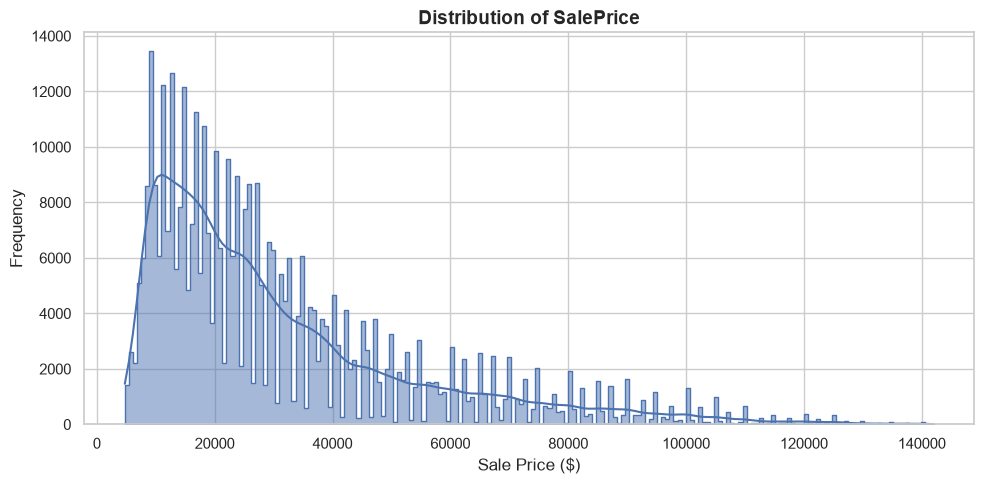

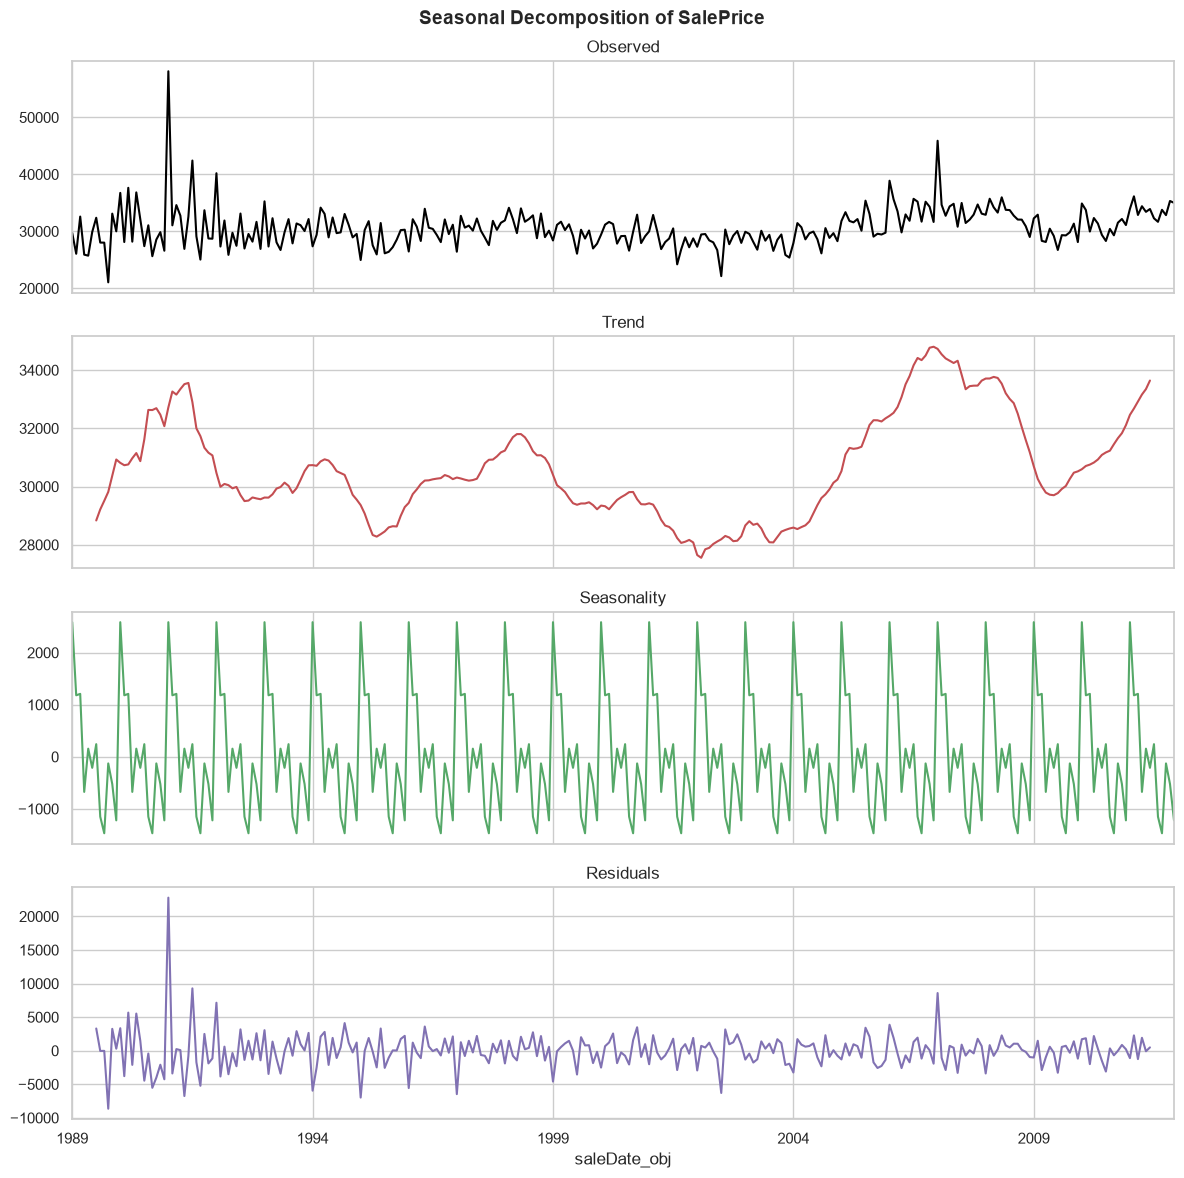

In [5]:
# EDA: Distribution of SalePrice and Seasonal Decomposition

plot_df = train_df.copy()

# Theme 
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# 1. Price Distribution Plot
plt.figure(figsize=(10, 5))
sns.histplot(plot_df["SalePrice"], kde=True, color="#4c72b0", element="step")
plt.title("Distribution of SalePrice", fontsize=14, fontweight='bold')
plt.xlabel("Sale Price ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(eda_plots_dir / "01_saleprice_distribution.png", dpi=300)  # Save the figure
plt.show()

# 2. Seasonal Decomposition Plot
# Calculate the average SalePrice for each month
plot_df["saleDate_obj"] = pd.to_datetime(
    plot_df["saleYear"].astype(str) + "-" + 
    plot_df["saleMonth"].astype(str) + "-01"
)

monthly_prices = plot_df.groupby("saleDate_obj")["SalePrice"].mean()
monthly_prices = monthly_prices.asfreq('MS')
decomposition = seasonal_decompose(monthly_prices, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
fig.suptitle("Seasonal Decomposition of SalePrice", fontsize=14, fontweight='bold')

decomposition.observed.plot(ax=axes[0], color='black')
axes[0].set_title('Observed', fontsize=12)

decomposition.trend.plot(ax=axes[1], color='#c44e52')
axes[1].set_title('Trend', fontsize=12)

decomposition.seasonal.plot(ax=axes[2], color='#55a868')
axes[2].set_title('Seasonality', fontsize=12)

decomposition.resid.plot(ax=axes[3], color='#8172b3')
axes[3].set_title('Residuals', fontsize=12)

plt.tight_layout()  
plt.savefig(eda_plots_dir / "02_saleprice_seasonal_decomposition.png", dpi=300)  # Save the figure
plt.show()

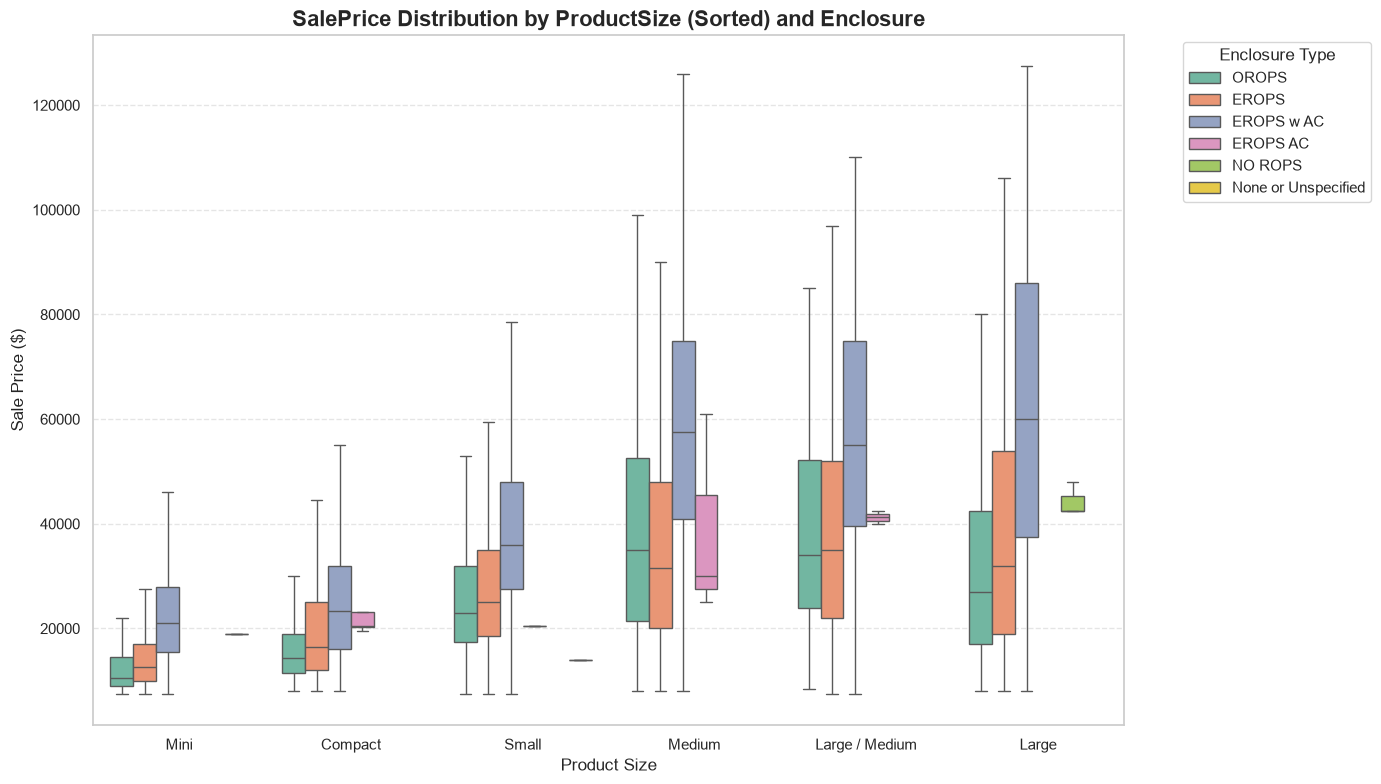

In [6]:
# EDA: SalePrice Distribution by ProductSize and Enclosure

# Define the order of ProductSize categories for better visualization
size_order = ["Mini", "Compact", "Small", "Medium", "Large / Medium", "Large"]
plot_df["ProductSize"] = pd.Categorical(
    plot_df["ProductSize"], 
    categories=size_order, 
    ordered=True
)

# Create a boxplot to visualize SalePrice distribution by ProductSize and Enclosure
plt.figure(figsize=(14, 8))
sns.boxplot(
    data=plot_df,
    x="ProductSize",
    y="SalePrice",
    hue="Enclosure",
    palette="Set2",
    showfliers=False
)

plt.title("SalePrice Distribution by ProductSize (Sorted) and Enclosure", fontsize=16, fontweight='bold')
plt.xlabel("Product Size", fontsize=12)
plt.ylabel("Sale Price ($)", fontsize=12)
plt.legend(title='Enclosure Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(eda_plots_dir / "03_saleprice_by_productsize_enclosure.png", dpi=300)  # Save the figure
plt.show()

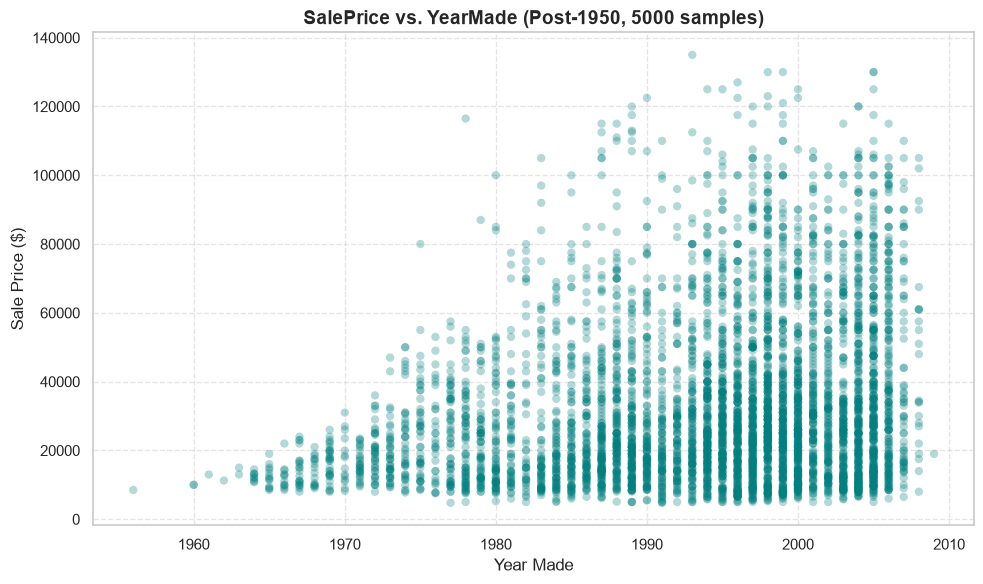

In [7]:
# EDA: SalePrice vs. YearMade (Scatter Plot)
plt.figure(figsize=(10, 6))


plot_df = plot_df[plot_df["YearMade"] > 1950].sample(5000, random_state=42)

plt.scatter(plot_df["YearMade"], plot_df["SalePrice"], 
            alpha=0.3, c="teal", edgecolors="none")

plt.title("SalePrice vs. YearMade (Post-1950, 5000 samples)", fontsize=14, fontweight='bold')
plt.xlabel("Year Made")
plt.ylabel("Sale Price ($)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(eda_plots_dir / "04_saleprice_vs_yearmade.png", dpi=300)  # Save the figure
plt.show()

# Preprocessing Pipeline (Imputation and Encoding)

In [8]:
# Split training and validation data into features and labels

X_train = train_df.drop("SalePrice", axis=1).copy()
y_train = train_df["SalePrice"].copy()

X_valid = valid_df.drop("SalePrice", axis=1).copy()
y_valid = valid_df["SalePrice"].copy()


In [9]:
# Identify categorical and numerical features

time_cols = ['saleYear', 'saleMonth', 'saleDay', 'saleDayofweek', 'saleDayofyear']

for col in time_cols:
    X_train[col] = X_train[col].astype(int)
    X_valid[col] = X_valid[col].astype(int)

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=["int64", "float64"]
).columns.tolist()

print(f"[INFO] Number of numerical features: {len(numerical_features)}")
print(f"[INFO] Numerical features: {numerical_features}")
print(f"[INFO] Number of categorical features: {len(categorical_features)}")
print(f"[INFO] Categorical features: {categorical_features}")

[INFO] Number of numerical features: 12
[INFO] Numerical features: ['SalesID', 'MachineID', 'ModelID', 'datasource', 'auctioneerID', 'YearMade', 'MachineHoursCurrentMeter', 'saleYear', 'saleMonth', 'saleDay', 'saleDayofweek', 'saleDayofyear']
[INFO] Number of categorical features: 44
[INFO] Categorical features: ['UsageBand', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc', 'fiModelSeries', 'fiModelDescriptor', 'ProductSize', 'fiProductClassDesc', 'state', 'ProductGroup', 'ProductGroupDesc', 'Drive_System', 'Enclosure', 'Forks', 'Pad_Type', 'Ride_Control', 'Stick', 'Transmission', 'Turbocharged', 'Blade_Extension', 'Blade_Width', 'Enclosure_Type', 'Engine_Horsepower', 'Hydraulics', 'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control', 'Tire_Size', 'Coupler', 'Coupler_System', 'Grouser_Tracks', 'Hydraulics_Flow', 'Track_Type', 'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb', 'Pattern_Changer', 'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type', 'Travel_Controls', 'Differential_Type', 'Ste

In [10]:
# Define Preprocessing Pipeline

# 1. numerical pipeline: Fill missing values with median
num_pipeline = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))]
)

# 2. categorical pipeline: Fill missing values with "missing" and apply Ordinal Encoding
cat_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing"),),
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),),
    ]
)

# 3. Combine the pipelines into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, numerical_features),
        ("cat", cat_pipeline, categorical_features),
    ],
    remainder="drop",
)

# 4. Preprocess the training and validation data
X_train_preprocessed = preprocessor.fit_transform(X_train)  # fit on training data only to prevent data leakage
X_valid_preprocessed = preprocessor.transform(X_valid)

# Log transformation (BETTER FOR RMSLE)
y_train_log = np.log(y_train)
y_valid_log = np.log(y_valid)


print(f"[INFO] X_train Shape: {X_train_preprocessed.shape}")
print(f"[INFO] X_valid Shape: {X_valid_preprocessed.shape}")

[INFO] X_train Shape: (401125, 56)
[INFO] X_valid Shape: (11573, 56)


# Modelling - LightGBM

In [11]:
# LightGBM Regressor Model

# Baseline LightGBM 
lgb_baseline = LGBMRegressor(
    n_estimators=100, random_state=42, n_jobs=-1, verbose=-1
)

# Train the baseline LightGBM model and measure training time
start_time = time.time()
lgb_baseline.fit(X_train_preprocessed, y_train_log)
lgb_baseline_train_time = time.time() - start_time



In [12]:
# Evaluate the model using RMSLE

# Make predictions on training and validation sets
lgb_base_train_preds = lgb_baseline.predict(X_train_preprocessed)
lgb_base_valid_preds = lgb_baseline.predict(X_valid_preprocessed)

# Use np.clip to prevent negative predictions in extreme cases
lgb_base_train_preds = np.clip(lgb_base_train_preds, 0, None)
lgb_base_valid_preds = np.clip(lgb_base_valid_preds, 0, None)

# Calculate RMSLE and R2 score in log space
lgb_base_train_rmsle = root_mean_squared_error(
    y_train_log, lgb_base_train_preds
)
lgb_base_valid_rmsle = root_mean_squared_error(
    y_valid_log, lgb_base_valid_preds
)
lgb_base_valid_r2 = r2_score(y_valid_log, lgb_base_valid_preds)

# Calculate MAE in actual price space
y_valid_actual = np.expm1(y_valid_log)
lgb_base_valid_preds_actual = np.expm1(lgb_base_valid_preds)
lgb_base_valid_mae = mean_absolute_error(
    y_valid_actual, lgb_base_valid_preds_actual
)

print("="*50)
print("Step 1: Baseline LightGBM")
print("="*50)
print(f"Training Time : {lgb_baseline_train_time:.2f} seconds")
print(f"Train RMSLE   : {lgb_base_train_rmsle:.4f}")
print(f"Valid RMSLE   : {lgb_base_valid_rmsle:.4f}")
print(f"Valid MAE ($) : ${lgb_base_valid_mae:.2f}")
print(f"Valid R2      : {lgb_base_valid_r2:.4f}")
print("="*50)

Step 1: Baseline LightGBM
Training Time : 1.07 seconds
Train RMSLE   : 0.2504
Valid RMSLE   : 0.2874
Valid MAE ($) : $7369.87
Valid R2      : 0.8469


# Modelling - Stacking

- Level 1
    - LightGBM (Non-linear Tree)
    - Ridge
    
- Level 2
    - Ridge (Blending Meta-Model)

In [13]:
# Define and fit Stacking model

# Level 1
# Ridge gets scaled inside its own sub-pipeline
ridge_model = Pipeline(
    steps=[
        ("scaler", StandardScaler(with_mean=False)), # with_mean=False handles sparse matrices cleanly
        ("regressor", Ridge(alpha=100.0, solver="lsqr"))
    ]
)

level1_models = [
    ("lgb", LGBMRegressor(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1),),
    ("Ridge", ridge_model,), 
]

# Level 2
meta_model = Ridge(alpha=1.0)

# 2-Level Stacking Regressor
stacking_baseline = StackingRegressor(
    estimators=level1_models, final_estimator=meta_model, cv=5, n_jobs=-1
)

# Fitting
print("[INFO] Fitting Lightweight Stacking Baseline (LGBM + Ridge -> Ridge) ...")
start_time = time.time()
stacking_baseline.fit(X_train_preprocessed, y_train_log)
stacking_train_time = time.time() - start_time

[INFO] Fitting Lightweight Stacking Baseline (LGBM + Ridge -> Ridge) ...


In [14]:
# Predict and evaluate the Stacking Regressor

# Make predictions on training and validation sets
stack_train_preds = stacking_baseline.predict(X_train_preprocessed)
stack_valid_preds = stacking_baseline.predict(X_valid_preprocessed)

# Use np.clip to prevent negative predictions in extreme cases
stack_train_preds = np.clip(stack_train_preds, 0, None)
stack_valid_preds = np.clip(stack_valid_preds, 0, None)

# Calculate Log-scale Metrics (RMSLE & R2)
stack_train_rmsle = root_mean_squared_error(y_train_log, stack_train_preds)
stack_valid_rmsle = root_mean_squared_error(y_valid_log, stack_valid_preds)
stack_valid_r2 = r2_score(y_valid_log, stack_valid_preds)

# Convert predictions back to actual dollar amounts for MAE ($)
y_valid_actual = np.expm1(y_valid_log)
stack_valid_preds_actual = np.expm1(stack_valid_preds)
stack_valid_mae = mean_absolute_error(
    y_valid_actual, stack_valid_preds_actual
)


# Print Results
print("=" * 50)
print("Step 2: Lightweight Stacking (LGBM + Ridge -> Ridge)")
print("=" * 50)
print(f"Training Time : {stacking_train_time:.2f} seconds")
print(f"Train RMSLE   : {stack_train_rmsle:.4f}")
print(f"Valid RMSLE   : {stack_valid_rmsle:.4f}")
print(f"Valid MAE ($) : ${stack_valid_mae:,.2f}")
print(f"Valid R2      : {stack_valid_r2:.4f}")
print("=" * 50)

Step 2: Lightweight Stacking (LGBM + Ridge -> Ridge)
Training Time : 12.82 seconds
Train RMSLE   : 0.2525
Valid RMSLE   : 0.2871
Valid MAE ($) : $7,259.97
Valid R2      : 0.8472


# Compare Baseline Models

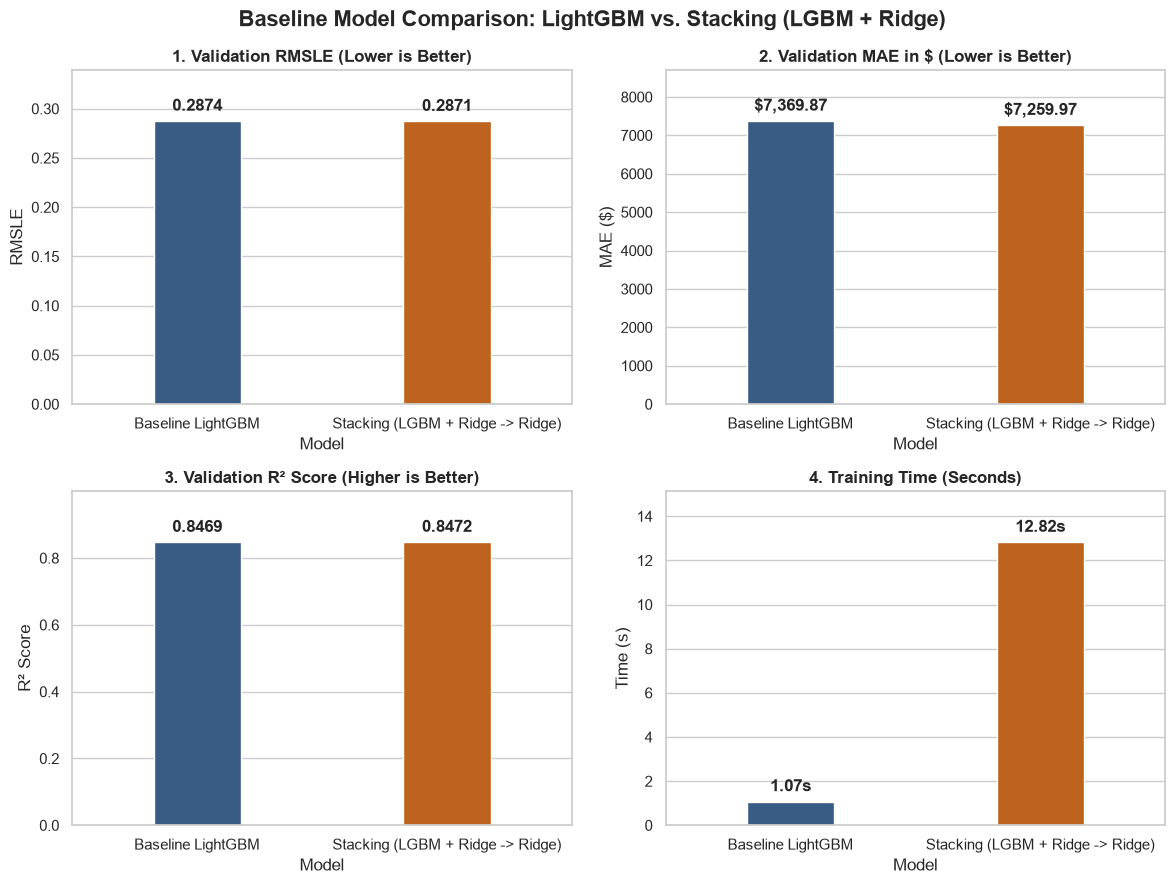

In [15]:
# Comparing Baseline LightGBM and Stacking Model Performance

# 1. Create Model Comparison Summary DataFrame
comparison_data = [
    {
        "Model": "Baseline LightGBM",
        "Train RMSLE": lgb_base_train_rmsle,
        "Valid RMSLE": lgb_base_valid_rmsle,
        "Valid MAE ($)": round(lgb_base_valid_mae, 2),
        "Valid R2": round(lgb_base_valid_r2, 4),
        "Training Time (s)": round(lgb_baseline_train_time, 2),
    },
    {
        "Model": "Stacking (LGBM + Ridge -> Ridge)",
        "Train RMSLE": stack_train_rmsle,
        "Valid RMSLE": stack_valid_rmsle,
        "Valid MAE ($)": round(stack_valid_mae, 2),
        "Valid R2": round(stack_valid_r2, 4),
        "Training Time (s)": round(stacking_train_time, 2),
    },
]

comparison_df = pd.DataFrame(comparison_data)
comparison_df.to_csv(evaluation_plots_dir / "baseline_model_comparison.csv", index=False)


# Helper function to annotate bar plots with values
def annotate_bars(ax, fmt_type="float", decimals=4, prefix="", suffix="", y_margin=1.18):
    # Get the heights of the bars to set y-axis limit
    heights = [
        p.get_height() for p in ax.patches if not pd.isna(p.get_height())
    ]
    if heights:
        ax.set_ylim(0, max(heights) * y_margin)    

    # Annotate each bar with its value
    for p in ax.patches:
        val = p.get_height()
        if fmt_type == "currency":
            label = f"{prefix}${val:,.2f}{suffix}"
        elif fmt_type == "float":
            label = f"{prefix}{val:.{decimals}f}{suffix}"
        else:
            label = f"{prefix}{val}{suffix}"

        ax.annotate(
            label,
            (p.get_x() + p.get_width() / 2.0, val),
            ha="center",
            va="bottom",
            xytext=(0, 5),
            textcoords="offset points",
            fontweight="bold",
        )


# 2. Visualization Plot (3 Subplots)
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
sns.set_theme(style="whitegrid")

palette = ["#2b5c8f", "#d95f02"]

# (a)) Validation RMSLE
sns.barplot(
    data=comparison_df,
    x="Model",
    y="Valid RMSLE",
    hue="Model",
    ax=axes[0, 0],
    palette=palette,
    legend=False,
    width=0.35,
)
axes[0, 0].set_title("1. Validation RMSLE (Lower is Better)", fontweight="bold")
axes[0, 0].set_ylabel("RMSLE")
annotate_bars(axes[0, 0], fmt_type="float", decimals=4)

# (b)) Validation MAE
sns.barplot(
    data=comparison_df,
    x="Model",
    y="Valid MAE ($)",
    hue="Model",
    ax=axes[0, 1],
    palette=palette,
    legend=False,
    width=0.35,
)
axes[0, 1].set_title("2. Validation MAE in $ (Lower is Better)", fontweight="bold")
axes[0, 1].set_ylabel("MAE ($)")
annotate_bars(axes[0, 1], fmt_type="currency")

# (c)) Validation R2
sns.barplot(
    data=comparison_df,
    x="Model",
    y="Valid R2",
    hue="Model",
    ax=axes[1, 0],
    palette=palette,
    legend=False,
    width=0.35,
)
axes[1, 0].set_title("3. Validation R² Score (Higher is Better)", fontweight="bold")
axes[1, 0].set_ylabel("R² Score")
annotate_bars(axes[1, 0], fmt_type="float", decimals=4)

# (d)) Training Time
sns.barplot(
    data=comparison_df,
    x="Model",
    y="Training Time (s)",
    hue="Model",
    ax=axes[1, 1],
    palette=palette,
    legend=False,
    width=0.35,
)
axes[1, 1].set_title("4. Training Time (Seconds)", fontweight="bold")
axes[1, 1].set_ylabel("Time (s)")
annotate_bars(axes[1, 1], fmt_type="float", decimals=2, suffix="s")

plt.suptitle("Baseline Model Comparison: LightGBM vs. Stacking (LGBM + Ridge)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(evaluation_plots_dir / "01_baseline_model_comparison.png", dpi=300)
plt.show()


In [16]:
# Optional: Save the baseline model

joblib.dump(lgb_baseline, models_dir / "baseline_lightgbm_model.joblib")
joblib.dump(stacking_baseline, models_dir / "baseline_stacking_model.joblib")

['models\\baseline_stacking_model.joblib']

# Tuning & Evaluation - LightGBM

In [17]:
# Use predefined split for hyperparameter tuning with RandomizedSearchCV

X_all = np.vstack([X_train_preprocessed, X_valid_preprocessed])
y_all = np.concatenate([y_train_log, y_valid_log])

split_index = [-1] * len(X_train_preprocessed) + [0] * len(
    X_valid_preprocessed
)
pds = PredefinedSplit(test_fold=split_index)

In [18]:
# Tune LightGBM

param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [-1, 6, 8, 12],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0.0, 0.1, 1.0, 5.0],
    "reg_lambda": [0.0, 0.1, 1.0, 5.0],
}

lgb_base_for_search = LGBMRegressor(random_state=42, verbose=-1, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=lgb_base_for_search,
    param_distributions=param_distributions,
    n_iter=20, 
    scoring="neg_root_mean_squared_error",
    cv=pds,
    random_state=42,
    n_jobs=-1,
)

# Tune LightGBM with RandomizedSearchCV
print("[INFO] Tuning LightGBM with RandomizedSearchCV ...\n")
start_time = time.time()
random_search.fit(X_all, y_all)
lgb_tuning_time = time.time() - start_time

# Print the best parameters found
tuned_lgb_model = random_search.best_estimator_
print("Best LightGBM Parameters Found:")
for k, v in random_search.best_params_.items():
    print(f"   • {k}: {v}")

[INFO] Tuning LightGBM with RandomizedSearchCV ...

Best LightGBM Parameters Found:
   • subsample: 0.8
   • reg_lambda: 0.1
   • reg_alpha: 0.0
   • num_leaves: 127
   • n_estimators: 300
   • max_depth: 8
   • learning_rate: 0.1
   • colsample_bytree: 0.6


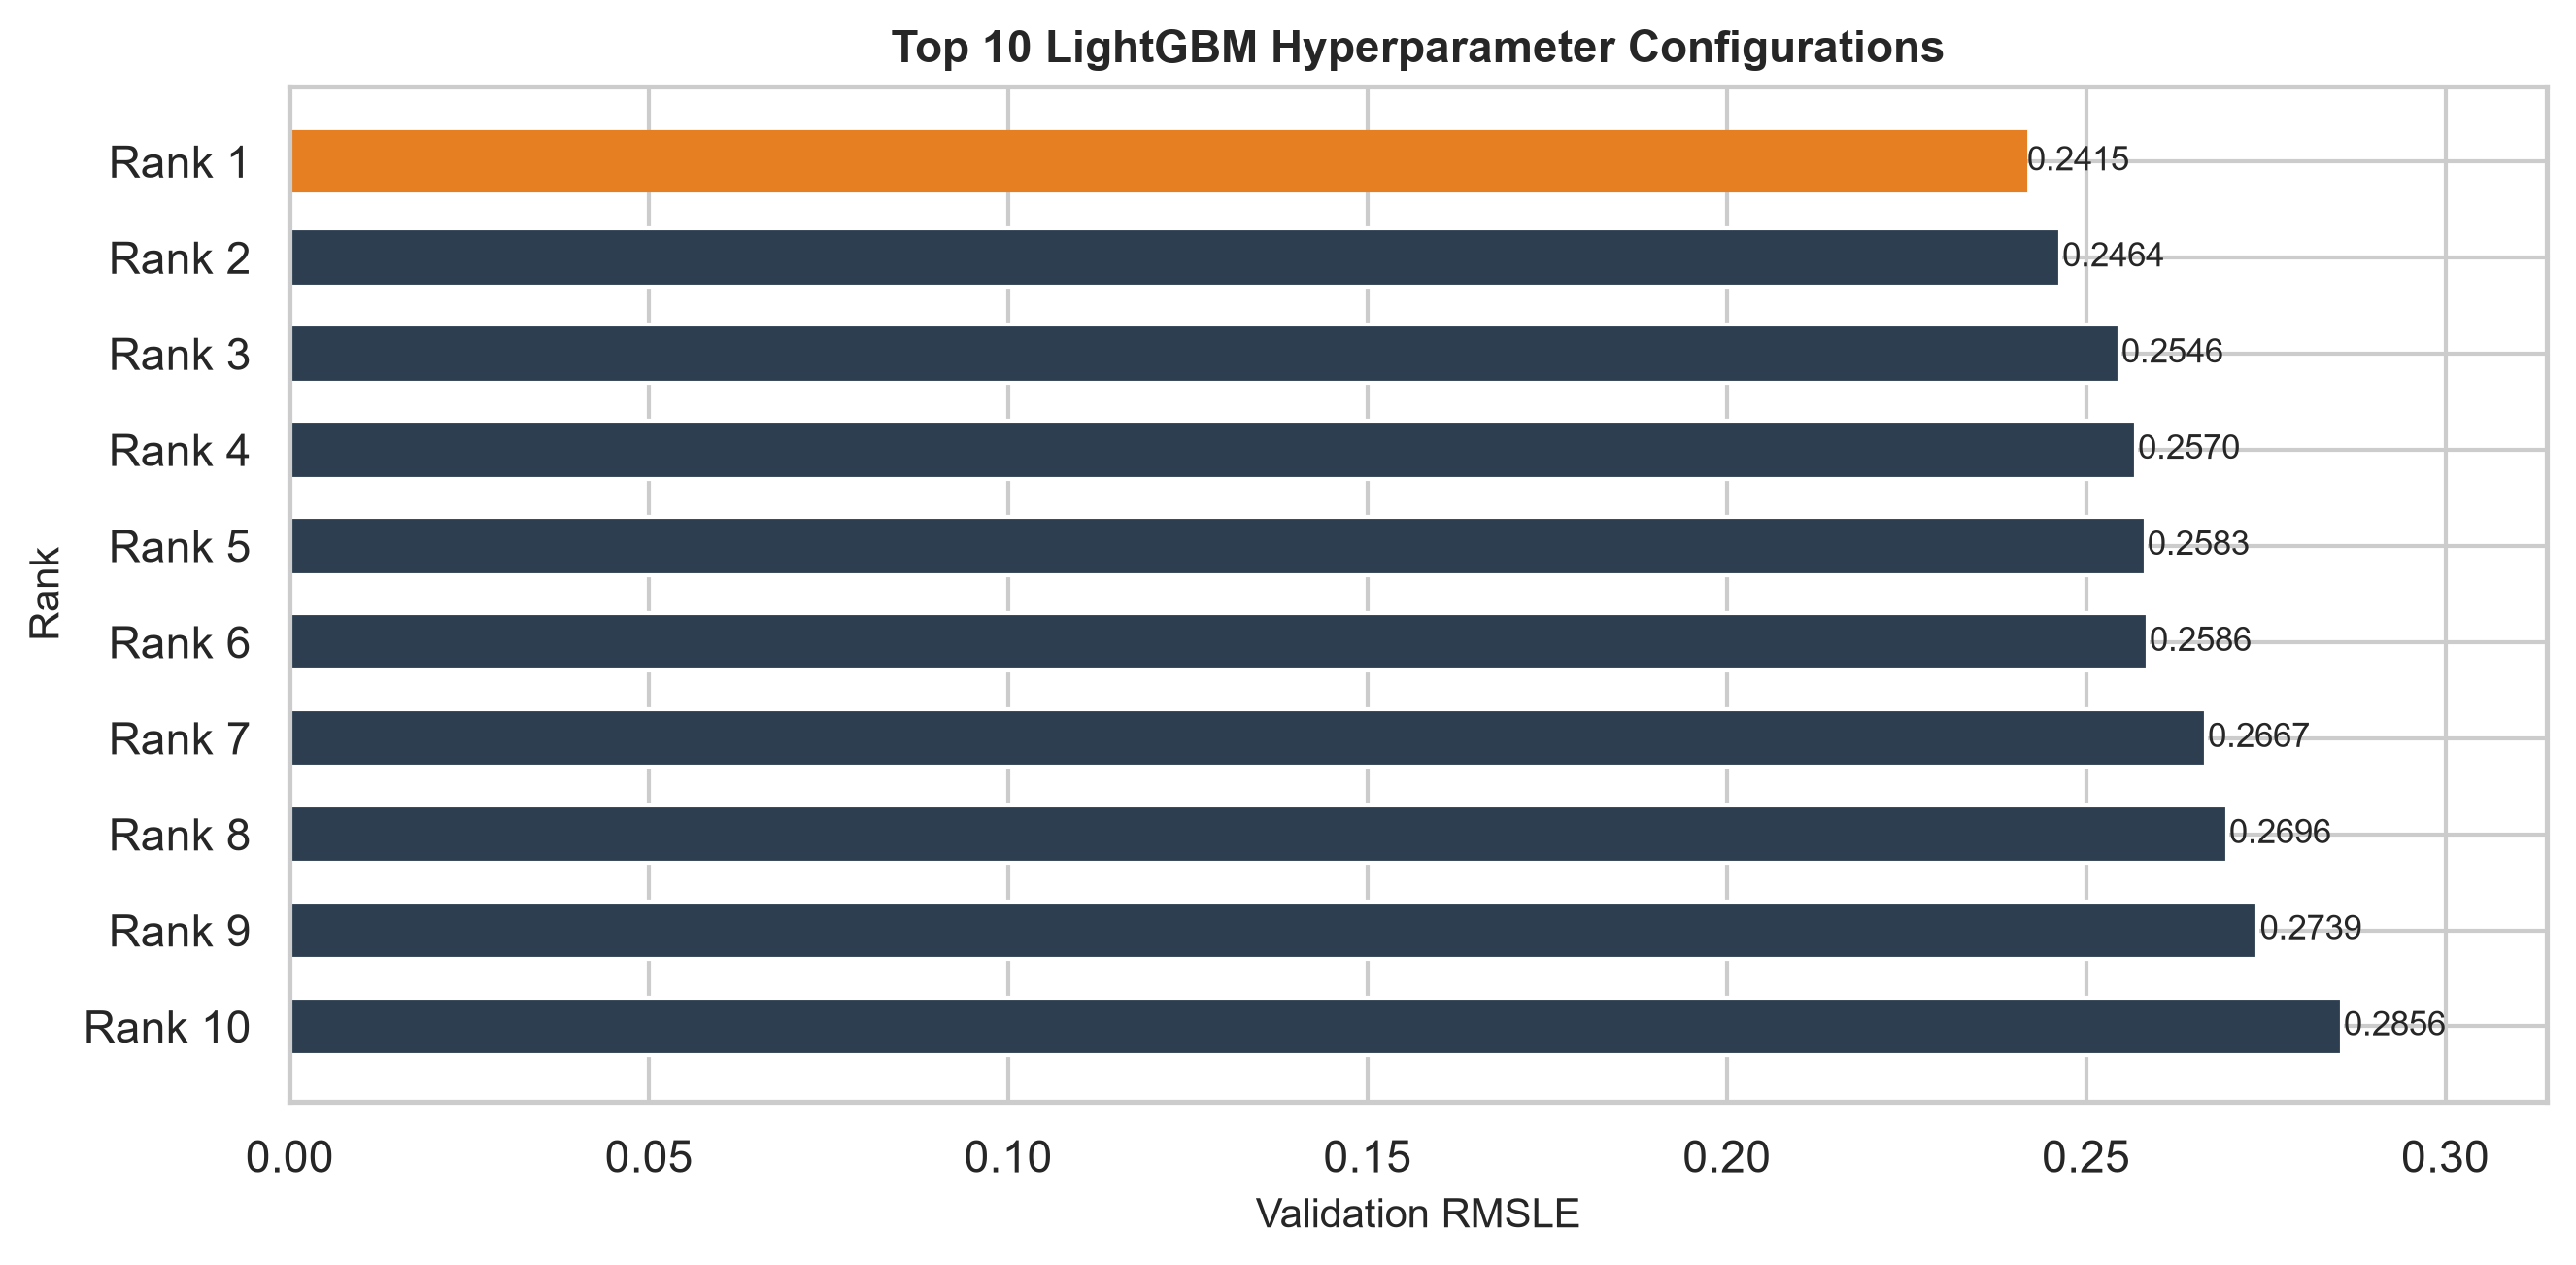

In [19]:
# Plot 1: Top 10 Configurations Ranking

results_df = pd.DataFrame(random_search.cv_results_)
results_df["mean_test_rmse"] = -results_df["mean_test_score"]
results_df = results_df.sort_values("mean_test_rmse").reset_index(drop=True)

plt.figure(figsize=(9, 4.5), dpi=300)
top_10 = results_df.head(10)
bars = plt.barh(
    range(len(top_10)),
    top_10["mean_test_rmse"],
    color="#2c3e50",
    height=0.6,
)
bars[0].set_color("#e67e22")  # Best model in orange

plt.yticks(range(len(top_10)), [f"Rank {i+1}" for i in range(len(top_10))])
plt.gca().invert_yaxis()
plt.xlabel("Validation RMSLE", fontsize=10)
plt.ylabel("Rank", fontsize=10)
plt.title("Top 10 LightGBM Hyperparameter Configurations",fontsize=11,fontweight="bold",)
plt.xlim(0, top_10["mean_test_rmse"].max() * 1.1)  # Add some padding to the x-axis

for i, bar in enumerate(bars):
    score = top_10["mean_test_rmse"].iloc[i]
    plt.text(
        bar.get_width() * 1.001,
        bar.get_y() + bar.get_height() / 2,
        f"{score:.4f}",
        va="center",
        fontsize=8.5,
    )

plt.tight_layout()
plt.savefig(tuning_plots_dir / "01_lgbm_top_10_configurations.png", dpi=300)
plt.show()

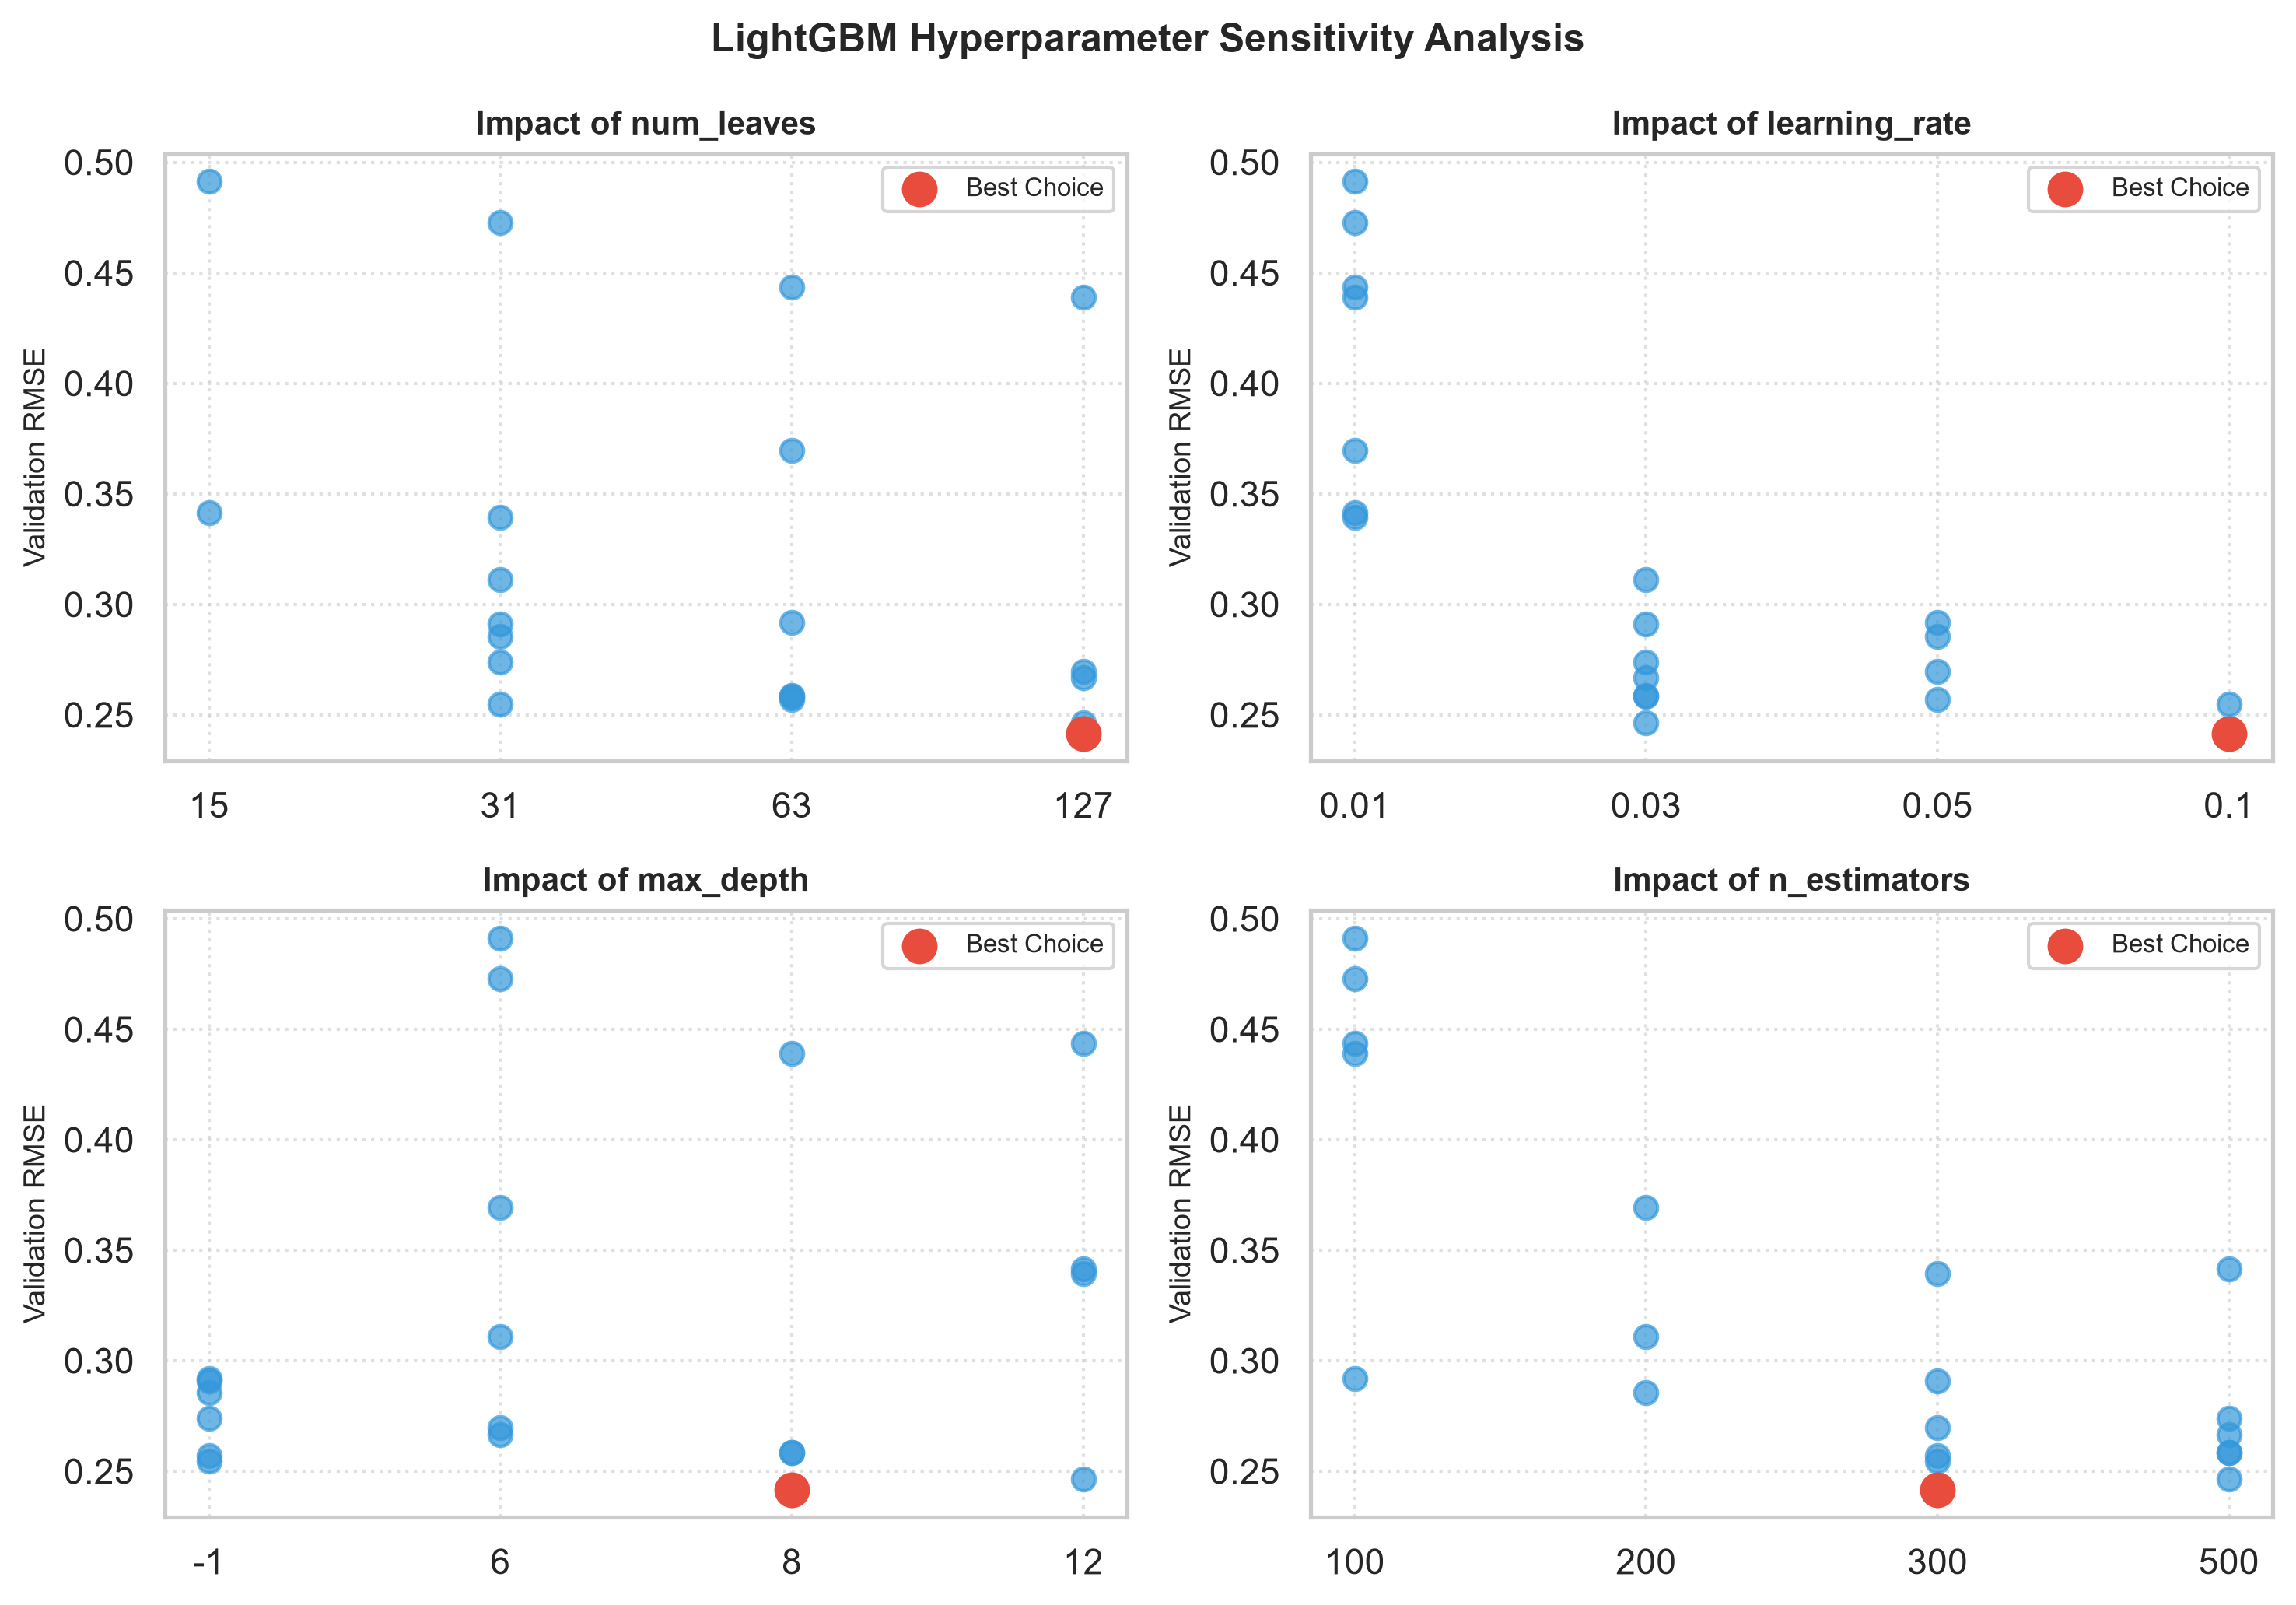

In [20]:
# Plot 2: Parameter Sensitivity (2x2 Grid)

params_to_plot = ["num_leaves", "learning_rate", "max_depth", "n_estimators"]
fig, axes = plt.subplots(2, 2, figsize=(10, 7), dpi=300)

for ax, param in zip(axes.flatten(), params_to_plot):
    param_col = f"param_{param}"

    # Sort results dataframe based on parameter values for proper X-axis ordering
    sorted_df = results_df.copy()
    sorted_df[param_col] = pd.to_numeric(sorted_df[param_col])
    sorted_df = sorted_df.sort_values(by=param_col)

    # Scatter of all trials with sorted numerical X values
    ax.scatter(
        sorted_df[param_col].astype(str),
        sorted_df["mean_test_rmse"],
        color="#3498db",
        alpha=0.7,
        s=50,
    )

    # Highlight best parameter
    best_val = str(random_search.best_params_[param])
    best_score = -random_search.best_score_
    ax.scatter(
        best_val,
        best_score,
        color="#e74c3c",
        s=100,
        zorder=5,
        label="Best Choice",
    )

    ax.set_title(f"Impact of {param}", fontsize=10, fontweight="bold")
    ax.set_ylabel("Validation RMSE", fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(fontsize=8, loc="best")

plt.suptitle(
    "LightGBM Hyperparameter Sensitivity Analysis",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(tuning_plots_dir / "02_lgb_tuning_sensitivity.png")
plt.show()

In [21]:
# Evaluate the tuned LightGBM model

tuned_lgb_train_preds = tuned_lgb_model.predict(X_train_preprocessed)
tuned_lgb_valid_preds = tuned_lgb_model.predict(X_valid_preprocessed)

# prevent negative predictions in extreme cases
tuned_lgb_train_preds = np.clip(tuned_lgb_train_preds, 0, None)
tuned_lgb_valid_preds = np.clip(tuned_lgb_valid_preds, 0, None)

# Train and Valid RMSLE and R2 in log space
tuned_lgb_train_rmsle = root_mean_squared_error(
    y_train_log, tuned_lgb_train_preds
)
tuned_lgb_valid_rmsle = root_mean_squared_error(
    y_valid_log, tuned_lgb_valid_preds
)
tuned_lgb_valid_r2 = r2_score(y_valid_log, tuned_lgb_valid_preds)

# Calculate MAE in actual price space
y_valid_actual = np.expm1(y_valid_log)
tuned_lgb_valid_preds_actual = np.expm1(tuned_lgb_valid_preds)
tuned_lgb_valid_mae = mean_absolute_error(
    y_valid_actual, tuned_lgb_valid_preds_actual
)

# Print the results of the tuned LightGBM model
print("=" * 50)
print("Step 3: Tuned LightGBM Results")
print("=" * 50)
print(f"Tuning Time   : {lgb_tuning_time:.2f} seconds")
print(f"Train RMSLE   : {tuned_lgb_train_rmsle:.4f}")
print(f"Valid RMSLE   : {tuned_lgb_valid_rmsle:.4f}")
print(f"Valid MAE ($) : ${tuned_lgb_valid_mae:,.2f}")
print(f"Valid R2      : {tuned_lgb_valid_r2:.4f}")
print("=" * 50)

Step 3: Tuned LightGBM Results
Tuning Time   : 79.78 seconds
Train RMSLE   : 0.2005
Valid RMSLE   : 0.2071
Valid MAE ($) : $5,092.09
Valid R2      : 0.9205


In [22]:
# Save the tuned models to disk
joblib.dump(tuned_lgb_model, models_dir / "tuned_lightgbm_model.joblib")

['models\\tuned_lightgbm_model.joblib']

# Tuning & Evaluation - Stacking

In [23]:
# Tune Stacking Regressor with the tuned LightGBM and Huber models

print("[INFO] Fitting Final Tuned Stacking Regressor ...")

level1_tuned_models = [
    ("tuned_lgb", tuned_lgb_model),
    ("Ridge", ridge_model)
]

meta_model = Ridge(alpha=1.0)

tuned_stacking = StackingRegressor(
    estimators=level1_tuned_models, 
    final_estimator=meta_model, 
    cv=5, 
    n_jobs=-1
)

start_time = time.time()
tuned_stacking.fit(X_train_preprocessed, y_train_log)
tuned_stacking_train_time = time.time() - start_time

[INFO] Fitting Final Tuned Stacking Regressor ...


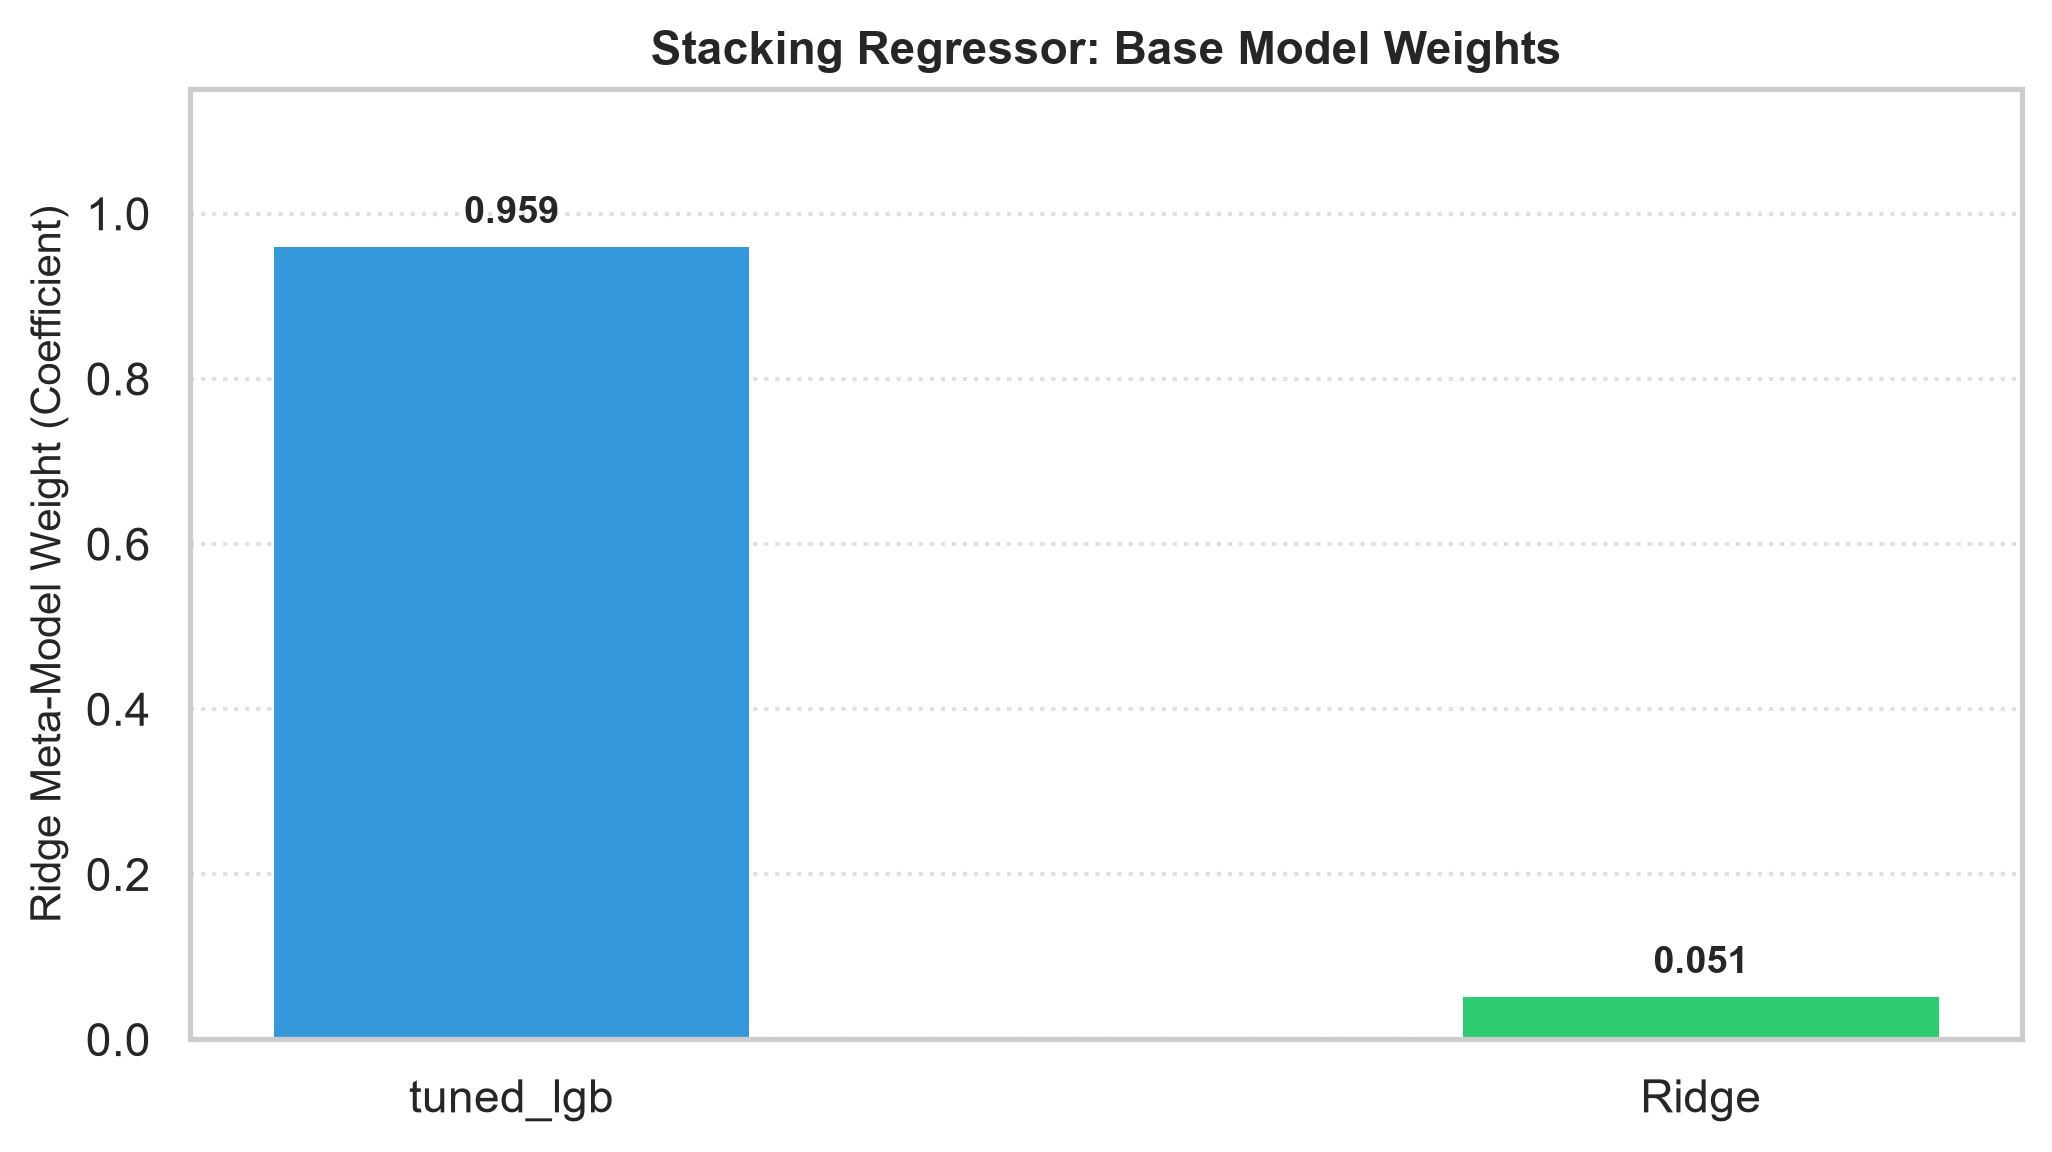

In [24]:
# Plot 1: Meta-Model Coefficients (Weights) of the Stacking Regressor

# 1. Extract Weights & Model Names
meta_weights = tuned_stacking.final_estimator_.coef_
base_model_names = [name for name, _ in level1_tuned_models]

# 2. Plot Meta-Model Coefficients
plt.figure(figsize=(7, 4), dpi=300)
bars = plt.bar(
    base_model_names,
    meta_weights,
    color=["#3498db", "#2ecc71"],
    width=0.4,
    edgecolor="none",
)

plt.ylabel("Ridge Meta-Model Weight (Coefficient)", fontsize=10)
plt.title("Stacking Regressor: Base Model Weights", fontsize=11, fontweight="bold")
plt.ylim(0, max(meta_weights) * 1.2)
plt.grid(visible=True, axis="y", linestyle=":", alpha=0.6)
plt.grid(visible=False, axis="x")

# Annotate values
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 0.02,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig(tuning_plots_dir / "03_stacking_meta_model_weights.png", dpi=300)
plt.show()

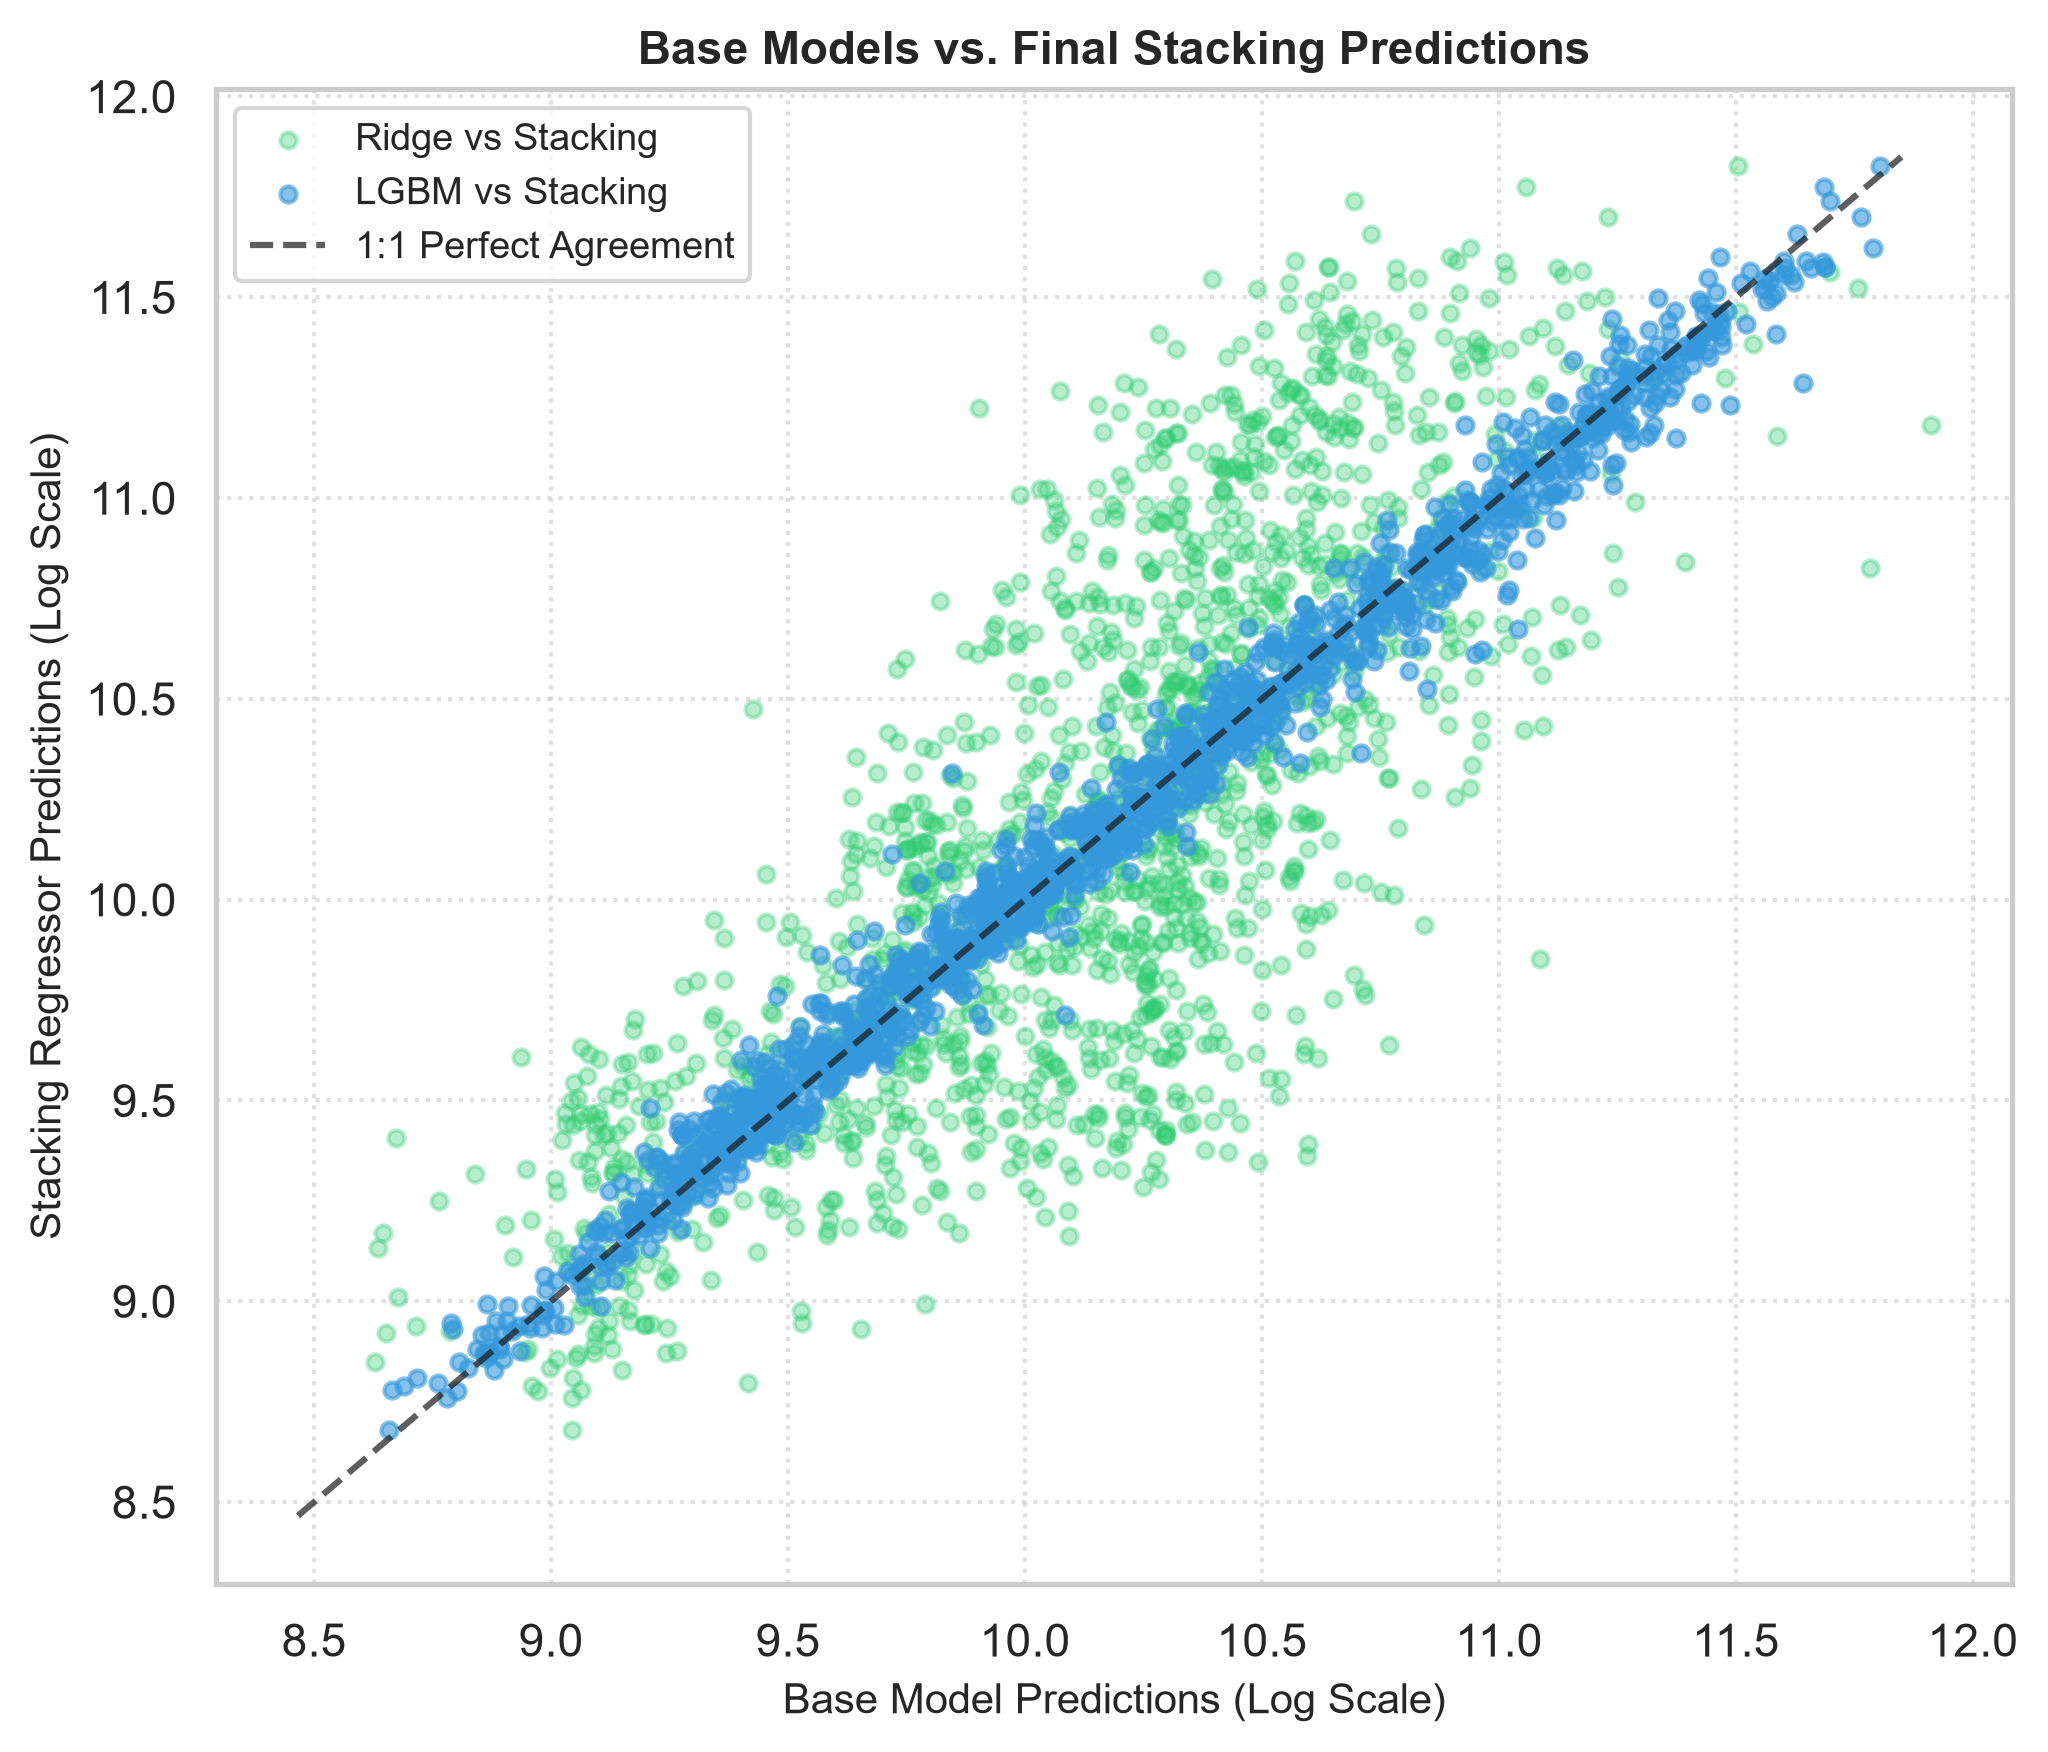

In [25]:
# Plot 2: Scatter Comparison of Base Models vs. Stacking Predictions

# 1. Get predictions from all models on Validation/Test Set
lgb_preds = tuned_lgb_model.predict(X_valid_preprocessed)
ridge_preds = level1_tuned_models[1][1].fit(X_train_preprocessed, y_train_log).predict(X_valid_preprocessed)
stack_preds = tuned_stacking.predict(X_valid_preprocessed)

# 2. Subsample points to prevent overplotting (e.g., max 1,500 samples)
np.random.seed(42)  # For reproducible sampling
n_samples = min(1500, len(stack_preds))
idx = np.random.choice(len(stack_preds), size=n_samples, replace=False)

# 3. Plot Scatter Comparison (Ridge first, LGBM on top using zorder)
plt.figure(figsize=(7, 6), dpi=300)

plt.scatter(
    ridge_preds[idx], 
    stack_preds[idx], 
    alpha=0.35, 
    label="Ridge vs Stacking", 
    color="#2ecc71", 
    s=15, 
    zorder=2
)

plt.scatter(
    lgb_preds[idx], 
    stack_preds[idx], 
    alpha=0.6, 
    label="LGBM vs Stacking", 
    color="#3498db", 
    s=15, 
    zorder=3
)

# Diagonal reference line
min_val = min(y_valid_log)
max_val = max(y_valid_log)
plt.plot([min_val, max_val], [min_val, max_val], "k--", label="1:1 Perfect Agreement", alpha=0.7, zorder=4)

plt.xlabel("Base Model Predictions (Log Scale)", fontsize=10)
plt.ylabel("Stacking Regressor Predictions (Log Scale)", fontsize=10)
plt.title("Base Models vs. Final Stacking Predictions", fontsize=11, fontweight="bold")
plt.legend(fontsize=9, loc="upper left")
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig(tuning_plots_dir / "04_stacking_pred_correlation.png", dpi=300)
plt.show()

In [26]:
# Evaluate Tuned Stacking

tuned_stack_train_preds = tuned_stacking.predict(X_train_preprocessed)
tuned_stack_valid_preds = tuned_stacking.predict(X_valid_preprocessed)

tuned_stack_train_preds = np.clip(tuned_stack_train_preds, 0, None)
tuned_stack_valid_preds = np.clip(tuned_stack_valid_preds, 0, None)

tuned_stack_train_rmsle = root_mean_squared_error(
    y_train_log, tuned_stack_train_preds
)
tuned_stack_valid_rmsle = root_mean_squared_error(
    y_valid_log, tuned_stack_valid_preds
)
tuned_stack_valid_r2 = r2_score(y_valid_log, tuned_stack_valid_preds)

y_valid_actual = np.expm1(y_valid_log)
tuned_stack_valid_preds_actual = np.expm1(tuned_stack_valid_preds)
tuned_stack_valid_mae = mean_absolute_error(
    y_valid_actual, tuned_stack_valid_preds_actual
)

print("=" * 50)
print("Step 4: Tuned Stacking (Tuned LGBM + Ridge -> Ridge)")
print("=" * 50)
print(f"Training Time : {tuned_stacking_train_time:.2f} seconds")
print(f"Train RMSLE   : {tuned_stack_train_rmsle:.4f}")
print(f"Valid RMSLE   : {tuned_stack_valid_rmsle:.4f}")
print(f"Valid MAE ($) : ${tuned_stack_valid_mae:,.2f}")
print(f"Valid R2      : {tuned_stack_valid_r2:.4f}")
print("=" * 50)

Step 4: Tuned Stacking (Tuned LGBM + Ridge -> Ridge)
Training Time : 22.44 seconds
Train RMSLE   : 0.2037
Valid RMSLE   : 0.2422
Valid MAE ($) : $6,037.12
Valid R2      : 0.8912


In [27]:
# Save the tuned stacking regressor to disk
joblib.dump(tuned_stacking, models_dir / "tuned_stacking_model.joblib")

['models\\tuned_stacking_model.joblib']

#  Comparing Tuned Models

In [28]:
# Final Model Comparison Summary

final_summary_data = [
    {
        "Model": "Baseline LightGBM",
        "Train RMSLE": lgb_base_train_rmsle,
        "Valid RMSLE": lgb_base_valid_rmsle,
        "Valid MAE ($)": round(lgb_base_valid_mae, 2),
        "Valid R2": round(lgb_base_valid_r2, 4),
        "Time (s)": round(lgb_baseline_train_time, 2),
    },
    {
        "Model": "Baseline Stacking",
        "Train RMSLE": stack_train_rmsle,
        "Valid RMSLE": stack_valid_rmsle,
        "Valid MAE ($)": round(stack_valid_mae, 2),
        "Valid R2": round(stack_valid_r2, 4),
        "Time (s)": round(stacking_train_time, 2),
    },
    {
        "Model": "Tuned LightGBM",
        "Train RMSLE": tuned_lgb_train_rmsle,
        "Valid RMSLE": tuned_lgb_valid_rmsle,
        "Valid MAE ($)": round(tuned_lgb_valid_mae, 2),
        "Valid R2": round(tuned_lgb_valid_r2, 4),
        "Time (s)": round(lgb_tuning_time, 2),
    },
    {
        "Model": "Tuned Stacking",
        "Train RMSLE": tuned_stack_train_rmsle,
        "Valid RMSLE": tuned_stack_valid_rmsle,
        "Valid MAE ($)": round(tuned_stack_valid_mae, 2),
        "Valid R2": round(tuned_stack_valid_r2, 4),
        "Time (s)": round(tuned_stacking_train_time, 2),
    },
]

final_results_df = pd.DataFrame(final_summary_data)

# Sort by Valid RMSLE (Ascending: lower is better)
final_results_df = final_results_df.sort_values(by="Valid RMSLE").reset_index(drop=True)

# Save to CSV
final_results_df.to_csv(models_dir / "final_model_comparison_summary.csv", index=False)

print("Final Model Comparison Summary:")
display(final_results_df)

Final Model Comparison Summary:


,Model,Train RMSLE,Valid RMSLE,Valid MAE ($),Valid R2,Time (s)
0,Tuned LightGBM,0.200531,0.207088,5092.09,0.9205,79.78
1,Tuned Stacking,0.203713,0.242201,6037.12,0.8912,22.44
2,Baseline Stacking,0.252508,0.287117,7259.97,0.8472,12.82
3,Baseline LightGBM,0.250448,0.287382,7369.87,0.8469,1.07


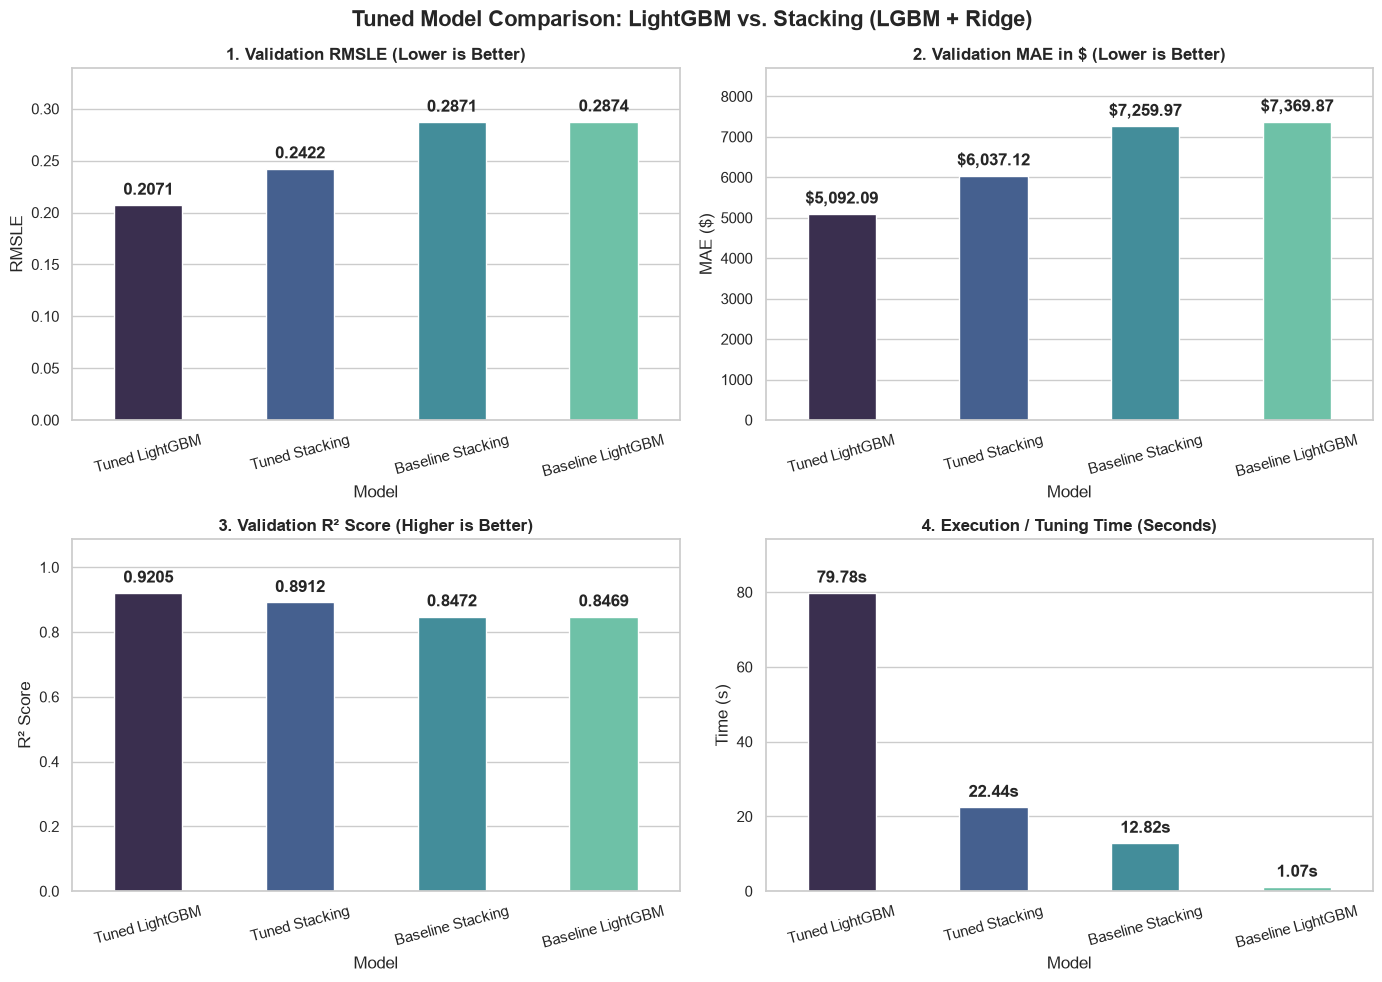

In [29]:
# Visualize the final model comparison results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.set_theme(style="whitegrid")
palette = "mako"

# 1. Validation RMSLE
sns.barplot(
    data=final_results_df,
    x="Model",
    y="Valid RMSLE",
    hue="Model",
    ax=axes[0, 0],
    palette=palette,
    legend=False,
    width=0.45,
)
axes[0, 0].set_title("1. Validation RMSLE (Lower is Better)", fontweight="bold")
axes[0, 0].set_ylabel("RMSLE")
axes[0, 0].tick_params(axis="x", rotation=15)
annotate_bars(axes[0, 0], fmt_type="float", decimals=4) 

# 2. Validation MAE ($)q
sns.barplot(
    data=final_results_df,
    x="Model",
    y="Valid MAE ($)",
    hue="Model",
    ax=axes[0, 1],
    palette=palette,
    legend=False,
    width=0.45,
)
axes[0, 1].set_title("2. Validation MAE in $ (Lower is Better)", fontweight="bold")
axes[0, 1].set_ylabel("MAE ($)")
axes[0, 1].tick_params(axis="x", rotation=15)
annotate_bars(axes[0, 1], fmt_type="currency")

# 3. Validation R² Score
sns.barplot(
    data=final_results_df,
    x="Model",
    y="Valid R2",
    hue="Model",
    ax=axes[1, 0],
    palette=palette,
    legend=False,
    width=0.45,
)
axes[1, 0].set_title("3. Validation R² Score (Higher is Better)", fontweight="bold")
axes[1, 0].set_ylabel("R² Score")
axes[1, 0].tick_params(axis="x", rotation=15)
annotate_bars(axes[1, 0], fmt_type="float", decimals=4)

# 4. Execution / Tuning Time
sns.barplot(
    data=final_results_df,
    x="Model",
    y="Time (s)",
    hue="Model",
    ax=axes[1, 1],
    palette=palette,
    legend=False,
    width=0.45,
)
axes[1, 1].set_title("4. Execution / Tuning Time (Seconds)", fontweight="bold")
axes[1, 1].set_ylabel("Time (s)")
axes[1, 1].tick_params(axis="x", rotation=15)
annotate_bars(axes[1, 1], fmt_type="float", decimals=2, suffix="s")

plt.suptitle("Tuned Model Comparison: LightGBM vs. Stacking (LGBM + Ridge)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(evaluation_plots_dir / "02_final_model_comparison.png", dpi=300)
plt.show()

In [30]:
# Save preprocessor and the tuned LightGBM model for future use

# 1. Combine fitted preprocessor and tuned LightGBM model into a single Pipeline
full_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("model", tuned_lgb_model)]
)

# 2. Save everything into the 'models/' folder
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

joblib.dump(full_pipeline, models_dir / "full_pipeline.joblib")
joblib.dump(numerical_features, models_dir / "numerical_features.joblib")
joblib.dump(categorical_features, models_dir / "categorical_features.joblib")

print("Successfully exported full_pipeline.joblib and feature lists!")

Successfully exported full_pipeline.joblib and feature lists!


# Model Interpretability

In [31]:
# # Sample a subset of the validation set for visualization and analysis 

# Get feature names from the preprocessor if available, otherwise create generic names
try:
    feature_names = preprocessor.get_feature_names_out()
except NameError:
    feature_names = [
        f"Feature_{i}" for i in range(X_valid_preprocessed.shape[1])
    ]

# Sample 2000 rows from the validation set
np.random.seed(42)
sample_size = min(2000, len(X_valid_preprocessed))
sample_idx = np.random.choice(
    len(X_valid_preprocessed), size=sample_size, replace=False
)

X_valid_sample = X_valid_preprocessed[sample_idx]
y_valid_sample = y_valid_log[sample_idx]

# Create DataFrame with column names for clean visualization
X_valid_sample_df = pd.DataFrame(X_valid_sample, columns=feature_names)

[INFO] Computing Permutation Importance for Tuned LightGBM...


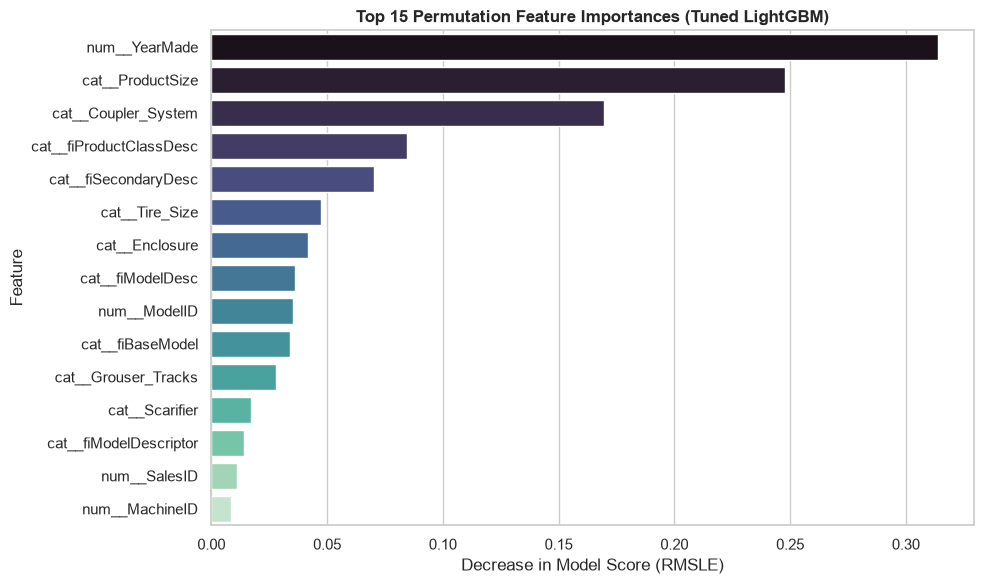

In [32]:
# Permutation Importance - Stacking Regressor

print("[INFO] Computing Permutation Importance for Tuned LightGBM...")

perm_result = permutation_importance(
    tuned_lgb_model,
    X_valid_sample,
    y_valid_sample,
    scoring="neg_root_mean_squared_error",
    n_repeats=5,
    random_state=42,
    n_jobs=1,  # n_jobs=1 prevents inter-process memory overhead on Windows
)

# Organize into DataFrame
perm_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": perm_result.importances_mean}
).sort_values(by="Importance", ascending=False)

# Plot Top 15 Features
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.barplot(
    data=perm_df.head(15),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="mako",
    legend=False,
)
plt.title(
    "Top 15 Permutation Feature Importances (Tuned LightGBM)",
    fontweight="bold",
)
plt.xlabel("Decrease in Model Score (RMSLE)")
plt.tight_layout()
plt.savefig(features_plots_dir / "01_permutation_importance_tuned_lgb.png", dpi=300)  # Save the figure
plt.show()


[INFO] Computing SHAP values using TreeExplainer...


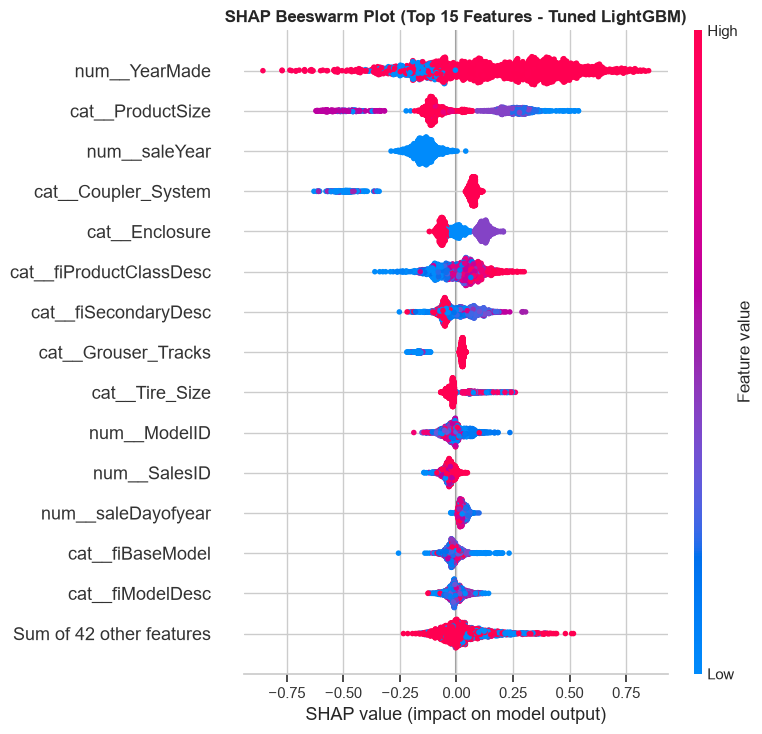

In [33]:
# SHAP Analysis - Tuned Random Forest Model

print("[INFO] Computing SHAP values using TreeExplainer...")

# TreeExplainer leverages LightGBM's native C++ implementation
explainer = shap.TreeExplainer(tuned_lgb_model)
shap_values = explainer(X_valid_sample_df)

# Plot SHAP Beeswarm Summary Plot
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("SHAP Beeswarm Plot (Top 15 Features - Tuned LightGBM)", fontweight="bold")
plt.tight_layout()
plt.savefig(features_plots_dir / "02_shap_beeswarm_tuned_tuned_lgb.png", dpi=300, bbox_inches='tight')
plt.show()